# Задача 1. Подготовка данных и EDA — Solar Power Plant

**Цель:** прогноз суммарной выработки AC-мощности солнечной станции на **48 часов** (2 суток).

**Данные:** [Solar Power Plant](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data/data). Показания погоды и датчиков инверторов солнечной электростанции в Индии.

**Метрики:** MAE, RMSE, MAPE, sMAPE (+ `no_zeros=True` для дневных часов).

**Режим:** offline batch-прогноз на 48 часов.

**Вывод по задаче 1** — раздел 3 в `README.md`.

В изначальной выборке данные разделены на две пары файлов по двум разным блокам солнечных понелей. Частота измерений 15 минут за 34 дня.

Каждая пара содержит:
* Generation Data - данные с датчиков инверторов в блоке
* Weather Sensor - данные погоды сеноров.

Структура датасетов:
* Generation Data
* * DATE_TIME - Дата и время.
* * PLANT_ID - Id блока.
* * SOURCE_KEY - Id инвертора в блоке.
* * DC_POWER - Постпившая на инвертор выработка (постоянный ток). kW.
* * AC_POWER - Выработка преобразованная в переменный ток инвертором. kW.
* * DAILY_YIELD - Кумулятивная выработка инвертора за день. kW.
* * TOTAL_YIELD - Кумулятивная выработка инвертора за всё веремя. kW.
* Weather Sensor
* * DATE_TIME - Дата и время.
* * PLANT_ID - Id блока.
* * SOURCE_KEY - Id сенсора блока.
* * AMBIENT_TEMPERATURE - Температура окружающей среды. Фаренгейты.
* * MODULE_TEMPERATURE - температура солнечных панелей. Фаренгейты.
* * IRRADIATION - Излучение солнца. Величина не известна.


Target - AC_POWER

**Предобработка**

1. Удаление PLANT_ID - Id блока идентичный в файле
2. Удаление DAILY_YIELD и TOTAL_YIELD
3. Удаление DC_POWER - Так как AC и DC линейно зависимы друг от друга
4. Группировка по времени - Так как прогнозирование выполняется для блока, а не для конкретного инвертора, данные по инверторам суммируются в общую выработку блока
5. Resampling на 1 час - так как частота в 15 минут излишняя для предсказания на двое суток вперёд
6. Объединение Generation Data и Weather Sensor
7. Пропуски заполняются интерполяцией с методом 'time'

**Важные моменты**

Для предсказания не важно, что выбрать за Target: DC_POWER или AC_POWER. Но так как AC_POWER является непосредственным выходом блока после выхода инвертора, по этой же причине сделано группировка.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from src.data import prepare_datasets, train_test_split

## 1. Загрузка и предобработка

In [2]:
df1 = prepare_datasets(
    '__input__/Solar Power Plant/Plant_1_Generation_Data.csv',
    '__input__/Solar Power Plant/Plant_1_Weather_Sensor_Data.csv',
    True
)

In [3]:
df2 = prepare_datasets(
    '__input__/Solar Power Plant/Plant_2_Generation_Data.csv',
    '__input__/Solar Power Plant/Plant_2_Weather_Sensor_Data.csv'
)

In [4]:
df1['unique_id'] = '1'
df2['unique_id'] = '2'

df = pd.concat([
    df1,
    df2
])

In [5]:
print(f'С: {df.index.min()}, По: {df.index.max()}')

С: 2020-05-15 00:00:00, По: 2020-06-17 23:00:00


In [6]:
df

,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,unique_id
DATE_TIME,,,,,
2020-05-15 00:00:00,0.0,25.012697,22.643083,0.0,1
2020-05-15 01:00:00,0.0,24.667328,22.411960,0.0,1
2020-05-15 02:00:00,0.0,24.986837,23.512072,0.0,1
2020-05-15 03:00:00,0.0,24.954589,24.126433,0.0,1
2020-05-15 04:00:00,0.0,24.276670,22.133106,0.0,1
...,...,...,...,...,...
2020-06-17 19:00:00,0.0,23.530150,22.480403,0.0,2
2020-06-17 20:00:00,0.0,23.676085,22.454153,0.0,2
2020-06-17 21:00:00,0.0,23.836589,23.519539,0.0,2


In [7]:
df.describe()

,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,1632.000000,1632.000000,1632.000000,1632.000000
mean,22980.443570,26.785090,31.897126,0.230181
std,29441.981007,3.923655,11.682310,0.299727
min,0.000000,20.677156,18.292424,0.000000
25%,0.000000,23.607697,22.401054,0.000000
50%,2953.903929,25.906137,26.686340,0.032134
75%,47813.549048,29.293801,41.196164,0.460186
max,109303.594642,38.660055,63.042589,1.011703


## 3. Визуализация целевого ряда

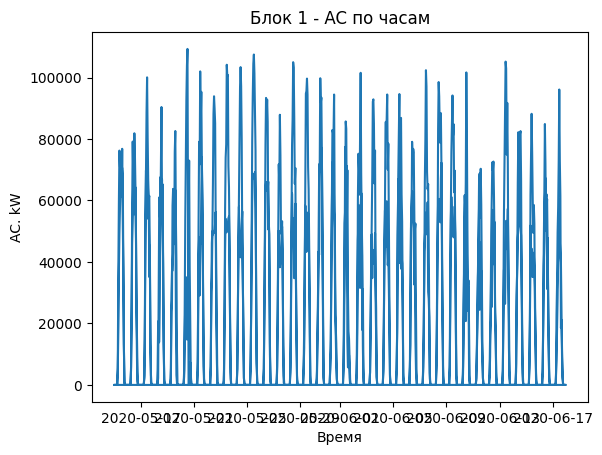

In [8]:
plt.plot(
    df.index,
    df['AC_POWER']
)

plt.title('Блок 1 - AC по часам')
plt.ylabel('AC. kW')
plt.xlabel('Время')

plt.show()

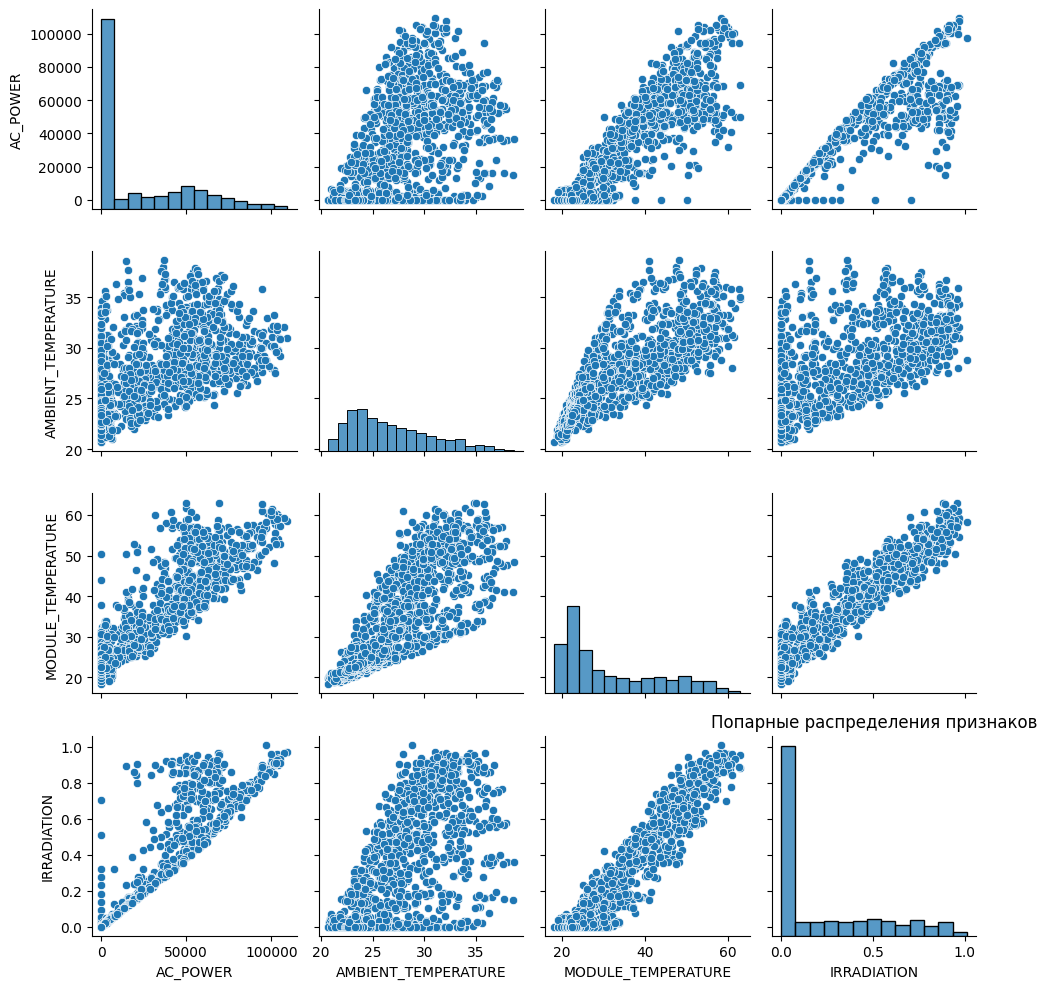

In [9]:
sns.pairplot(df)

plt.title('Попарные распределения признаков')

plt.tight_layout()
plt.show()

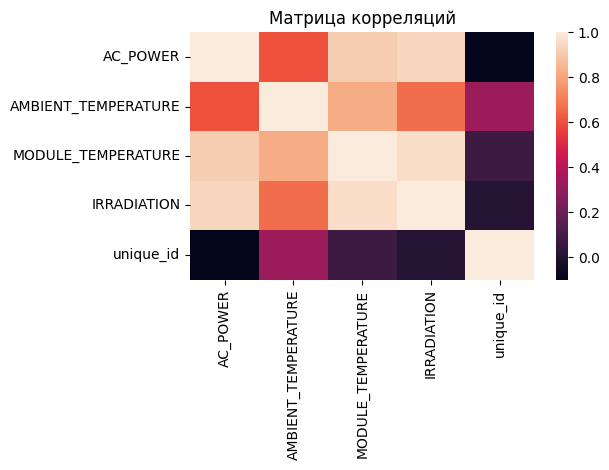

In [10]:
sns.heatmap(df.corr())

plt.title('Матрица корреляций')

plt.tight_layout()
plt.show()

## 4. Сезонность и декомпозиция

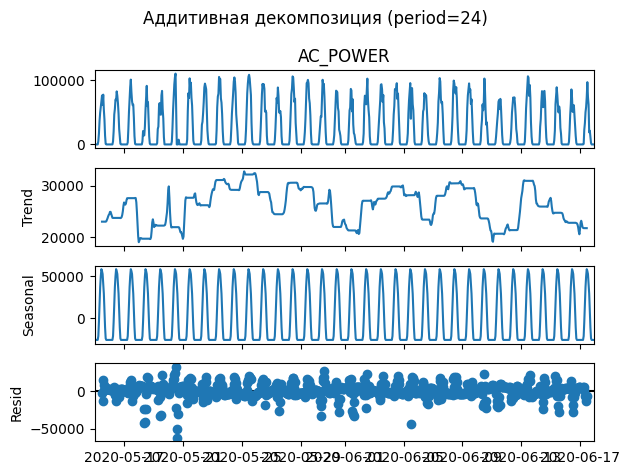

In [11]:
decomp = seasonal_decompose(df[df['unique_id'] == '1']['AC_POWER'], model='additive', period=24)
decomp.plot()

plt.suptitle('Аддитивная декомпозиция (period=24)')
plt.tight_layout()
plt.show()

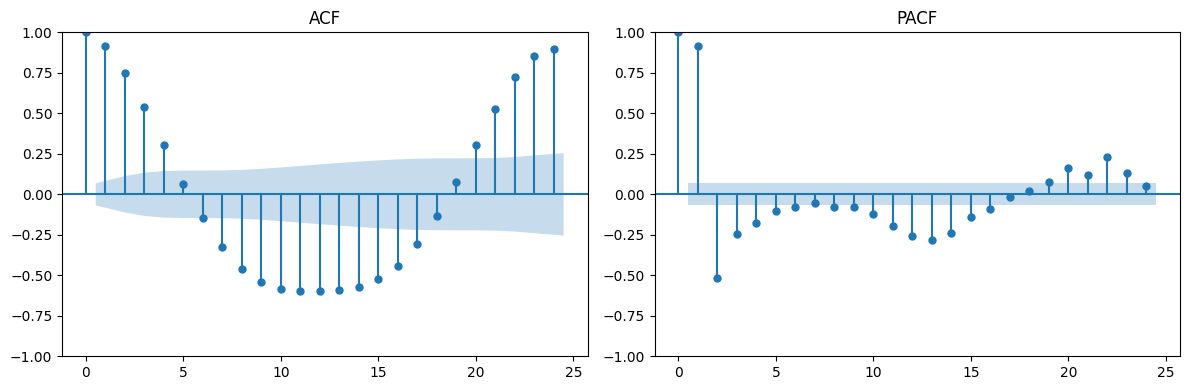

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df[df['unique_id'] == '1']['AC_POWER'], lags=24, ax=axes[0])
plot_pacf(df[df['unique_id'] == '1']['AC_POWER'], lags=24, ax=axes[1])

axes[0].set_title('ACF')
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

## 5. Стационарность (ADF)

In [13]:
def adf_report(target, title: str):
    stat, pvalue, *_ = adfuller(target.dropna())

    print(f'{title}: ADF={stat:.3f}, p-value={pvalue:.4f}')
    if pvalue < 0.05:
        print(f'{title} - Ряд Стационарен')
    else:
        print(f'{title} - Ряд Не стационарен')


adf_report(df[df['unique_id'] == '1']['AC_POWER'], 'Исходный ряд')
print()
adf_report(df[df['unique_id'] == '1']['AC_POWER'].diff(24), 'Ряд без сезонности (lag=24)')

Исходный ряд: ADF=-5.110, p-value=0.0000
Исходный ряд - Ряд Стационарен

Ряд без сезонности (lag=24): ADF=-15.954, p-value=0.0000
Ряд без сезонности (lag=24) - Ряд Стационарен


## 6. Постановка задачи и сохранение

* Исходный ряд **нестационарен** (ADF); после сезонного lag=24 — ближе к стационарности
* ~**46%** наблюдений с нулевой выработкой (ночные часы) — MAPE на полном ряду искажён; в моделях также оценка `no_zeros=True`
* Прогнозирование на **48 часов** (2 суток), hold-out — последние 48 уникальных меток времени × 2 блока
* Суточная **сезонность 24 ч**
* Target — `AC_POWER` (регрессия)
* Экзогенные признаки для ML/DL:
  * `AMBIENT_TEMPERATURE`
  * `MODULE_TEMPERATURE`
  * `IRRADIATION`

In [14]:
df_train, df_test = train_test_split(df, 48)

In [15]:
df_train.to_parquet('__output__/train.parquet')
df_test.to_parquet('__output__/test.parquet')